<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
《<a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a>》(从零构建大语言模型)一书的配套代码,作者 <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码仓库: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp?1" width="100px"></a>
</td>
</tr>
</table>

# 第7章: 微调以遵循指令 (Finetuning To Follow Instructions)

In [1]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.3.4
matplotlib version: 3.10.7
tiktoken version: 0.12.0
torch version: 2.9.0
tqdm version: 4.67.1
tensorflow version: 2.20.0


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/01.webp" width=500px>

**Figure 7.1 — 本章学习路线总览**

```
Pretraining (第5章)
    |
    v
加载预训练模型 (第7.5节)
    |
    v
准备指令数据集 (第7.2节)
    |
    v
组织训练批次 (第7.3节)
    |
    v
微调 LLM (第7.6节)
    |
    v
提取并保存响应 (第7.7节)
    |
    v
用另一个 LLM 评估 (第7.8节)
```

> 本章是全书的收官之作,将预训练的 GPT 模型微调为能够遵循人类指令的模型,涵盖数据准备、训练、评估的完整流程。


&nbsp;
## 7.1 指令微调简介 (Introduction to instruction finetuning)

- 在第5章中,我们看到预训练 LLM 的训练过程是让它学习逐词生成文本- 因此,预训练的 LLM 擅长文本补全,但不擅长遵循指令- 在本章中,我们教 LLM 更好地遵循指令

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/02.webp" width=500px>

**Figure 7.2 — 预训练与指令微调的对比**

```
预训练阶段:  无监督学习  ->  逐词预测下一个 token
                  |
                  v
指令微调阶段:  输入指令+输出答案  ->  学习遵循指令
                  |
                  v
              模型能够回答问题、执行任务
```

> 预训练让模型学会语言能力,而指令微调让模型学会听懂人类指令并作出正确响应——这是从文本补全到对话助手的关键一步。


- 本章涵盖的主题总结如下图所示<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/03.webp" width=500px>

**Figure 7.3 — 本章涵盖的主题概览**

```
7.1 指令微调简介
7.2 准备数据集
7.3 组织训练批次
7.4 创建数据加载器
7.5 加载预训练 LLM
7.6 微调 LLM
7.7 提取和保存响应
7.8 评估微调后的 LLM
7.9 总结
```

> 从数据准备到模型评估,本章涵盖了指令微调的完整工作流,每一步都配有代码实现。


&nbsp;
## 7.2 为监督指令微调准备数据集 (Preparing a dataset for supervised instruction finetuning)

- 我们将使用我为本章准备的指令数据集

In [2]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

"""
import urllib

def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
"""


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


- 上面从 JSON 文件加载的 `data` 列表中,每个条目是一个如下格式的字典

In [3]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


- 注意 `'input'` 字段可以为空:

In [4]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- 指令微调通常被称为"监督指令微调 (supervised instruction finetuning)",因为它涉及在显式提供输入-输出对的数据集上训练模型- 有多种方式可以将条目格式化为 LLM 的输入;下图展示了两种用于训练 Alpaca (https://crfm.stanford.edu/2023/03/13/alpaca.html) 和 Phi-3 (https://arxiv.org/abs/2404.14219) LLM 的示例格式

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/04.webp?2" width=500px>

**Figure 7.4 — Alpaca 与 Phi-3 的提示格式对比**

```
Alpaca 格式:
  ### Instruction:
  {指令}
  ### Input:
  {输入}
  ### Response:
  {响应}

Phi-3 格式:
  <|user|>
  {指令}<|end|>
  <|assistant|>
  {响应}<|end|>
```

> 不同的 LLM 使用不同的提示模板来格式化指令数据,本章采用 Alpaca 风格——这是指令微调最经典的模板之一。


- 在本章中,我们使用 Alpaca 风格的提示格式,这是指令微调最初的提示模板- 下面,我们将格式化要传递给 LLM 的输入

In [5]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- 包含输入字段的格式化响应如下所示

In [6]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- 下面是不包含输入字段的格式化响应

In [7]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


- 最后,在下一节准备 PyTorch 数据加载器之前,我们将数据集划分为训练集、验证集和测试集

In [8]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [9]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


&nbsp;
## 7.3 将数据组织为训练批次 (Organizing data into training batches)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/05.webp?1" width=500px>

**Figure 7.5 — 将指令数据组织为训练批次**

```
原始指令数据
    |
    v
分词 (tokenize)
    |
    v
按批次分组 + padding
    |
    v
输入张量 + 目标张量
    |
    v
送入 LLM 训练
```

> 将变长的指令文本转化为等长的批次张量,是微调 LLM 的核心数据工程步骤。


- 我们通过几个步骤来完成数据集批处理,如下图所示<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/06.webp?1" width=500px>

**Figure 7.6 — 数据批处理的步骤分解**

```
Step 1: InstructionDataset 预分词所有输入
    |
    v
Step 2: custom_collate_fn 按批次 padding
    |
    v
Step 3: 生成 input_ids 和 target_ids
    |
    v
Step 4: 移到目标设备 (GPU/CPU)
```

> 预分词 + 自定义 collate 函数的组合,让每个批次内部等长但不同批次可以不同长度,兼顾效率和灵活性。


- 首先,我们实现一个 `InstructionDataset` 类,对数据集中的所有输入进行预分词,类似于第6章的 `SpamDataset`<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/07.webp?1" width=500px>

**Figure 7.7 — InstructionDataset 类的工作方式**

```
InstructionDataset
  |
  +-- __init__: 遍历所有数据条目
  |     |
  |     v
  |   对每条指令+响应执行分词
  |     |
  |     v
  |   存储为 self.encoded_texts
  |
  +-- __getitem__: 返回编码后的文本
```

> InstructionDataset 在初始化时就完成全部分词工作,后续只需按索引取数据,大幅提升训练时的数据加载效率。


In [10]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- 与第6章类似,我们希望在一个批次中收集多个训练样本以加速训练;这需要将所有输入 padding 到相似的长度- 同样,我们使用 `<|endoftext|>` token 作为 padding token

In [11]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 在第6章中,我们将数据集中的所有样本 padding 到相同长度  - 在这里,我们采用更精细的方法,开发一个自定义的 "collate" 函数,可以传递给数据加载器  - 这个自定义 collate 函数将每个批次中的训练样本 padding 到相同长度(但不同批次可以有不同长度)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/08.webp?1" width=500px>

**Figure 7.8 — 自定义 collate 函数处理批次 padding**

```
批次内样本长度不一:
  [A: len=45] [B: len=60] [C: len=38]
         |
         v
  custom_collate_fn:
    1. 找到批次最大长度 = 60
    2. 用 <|endoftext|> (50256) 填充短样本
    3. 构造 input_ids + target_ids
         |
         v
  输出: [B, max_len] 等长张量
```

> 自定义 collate 函数实现了按批次动态 padding,避免了全局 padding 到最大长度带来的计算浪费。


In [12]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [13]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/09.webp?1" width=400px>

**Figure 7.9 — 仅返回输入的简单情况**

```
input_ids:  [t1, t2, t3, ..., tN, <pad>, <pad>]
                                        ^^^^^   ^^^^^
                                        padding  padding

(此时还没有 target_ids)
```

> 最初的 collate 函数只处理输入,但训练 LLM 还需要目标值——即输入右移一位后的序列。


- 上面我们只返回了 LLM 的输入;然而,对于 LLM 训练,我们还需要目标值- 与预训练 LLM 类似,目标是输入向右移动一个位置,这样 LLM 就学习预测下一个 token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/10.webp?1" width=400px>

**Figure 7.10 — 目标 = 输入右移一位**

```
input_ids:  [t1, t2, t3, t4, <pad>]
target_ids: [t2, t3, t4, <pad>, <pad>]
              ^--- 每个位置预测下一个 token

LLM 在位置 i 预测 target_ids[i]
```

> 通过将输入右移一位创建目标序列,LLM 在每个位置学习预测下一个 token,这是自回归语言模型的核心训练范式。


In [14]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [15]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- 接下来,我们引入一个 `ignore_index` 值,将所有 padding token ID 替换为新值;这个 `ignore_index` 的目的是让我们可以在损失函数中忽略 padding 值(稍后详述)<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/11.webp?1" width=400px>

**Figure 7.11 — 用 ignore_index 替换 padding token ID**

```
替换前:
  input_ids:  [..., 50256, 50256]
  target_ids: [..., 50256, 50256]

替换后:
  input_ids:  [..., 50256, 50256]  (输入不变)
  target_ids: [...,  -100,  -100]  (目标中替换为-100)
```

> 将目标中的 padding token ID 替换为 -100,使 PyTorch 的交叉熵损失自动忽略这些位置,避免无意义的 padding 干扰训练。


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/12.webp?2" width=500px>

**Figure 7.12 — 将 50256 替换为 -100 的完整流程**

```
原始 target:  [t1, t2, 50256, 50256]
                        |
                        v
替换后 target: [t1, t2,  -100,  -100]
                        |
                        v
cross_entropy(ignore_index=-100) -> 忽略这些位置
```

> 注意: 只替换 padding 对应的目标值,输入中的 padding 保留不变。第一个 <|endoftext|> token 的目标也保留,因为它能帮助模型学习何时结束响应。


- (此外,我们还引入了 `allowed_max_length`,以便在需要时限制样本的长度;如果你计划使用自己更长的数据集——超过 GPT-2 模型支持的 1024 token 上下文长度——这将非常有用)

In [16]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [17]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- 让我们看看替换为 -100 有什么效果- 为了说明,假设我们有一个类似第6章的小型分类任务,有 0 和 1 两个类别标签- 如果我们有以下 logits 值(模型最后一层的输出),我们计算如下损失

In [18]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- 现在,增加一个训练样本将如预期般影响损失值

In [19]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- 让我们看看如果将其中一个样本的类别标签替换为 -100 会发生什么

In [20]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- 如我们所见,这 3 个训练样本上的损失与之前 2 个训练样本计算的损失相同,这意味着交叉熵损失函数忽略了标签为 -100 的训练样本- 默认情况下,PyTorch 的 `cross_entropy(..., ignore_index=-100)` 设置会忽略标签为 -100 的样本- 使用这个 -100 `ignore_index`,我们可以忽略用于将训练样本 padding 到等长的额外 end-of-text (padding) token- 但是,我们不想忽略第一个 end-of-text (padding) token (50256) 的出现,因为它可以帮助向 LLM 发出响应已完成的信号

- 在实践中,也常见将对应于指令部分的目标 token ID 屏蔽掉,如下图所示(这是完成本章后的推荐读者练习)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/13.webp" width=600px>

**Figure 7.13 — 屏蔽指令部分的目标 token (高级技巧)**

```
完整序列:  [指令 tokens | 响应 tokens | <pad>]

目标掩码:  [-100 -100 ... | t1 t2 t3 ... | -100 -100]
             ^^^^^^^^^^^^   ^^^^^^^^^^^^   ^^^^^^^^^^
             屏蔽指令部分    只训练响应部分   屏蔽 padding

效果: 模型只学习生成响应, 不学习复述指令
```

> 屏蔽指令部分的目标 token 可以让模型专注于学习生成高质量响应,而非复述指令,这是提升指令遵循效果的进阶技巧。


&nbsp;
## 7.4 为指令数据集创建数据加载器 (Creating data loaders for an instruction dataset)

- 在本节中,我们使用 `InstructionDataset` 类和 `custom_collate_fn` 函数来实例化训练、验证和测试数据加载器

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/14.webp" width=500px>

**Figure 7.14 — 数据加载器的整体工作流**

```
InstructionDataset
        |
        v
DataLoader(collate_fn=custom_collate_fn)
        |
        v
  每个迭代返回:
    input_batch:  [B, max_len]
    target_batch: [B, max_len]
    (直接在目标设备上)
```

> 数据加载器整合了 InstructionDataset 和 custom_collate_fn,自动完成分词、padding、设备转移,直接产出可训练的张量。


- 之前的 `custom_collate_fn` 函数的另一个额外细节是,我们现在直接将数据移动到目标设备(例如 GPU),而不是在主训练循环中完成,这提高了效率,因为当 `custom_collate_fn` 作为数据加载器的一部分时,它可以作为后台进程执行- 使用 Python `functools` 标准库中的 `partial` 函数,我们创建一个新函数,其中原函数的 `device` 参数已预先填充

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [22]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

- 接下来,我们像前几章一样实例化数据加载器,不同之处是我们现在为批处理过程提供了自己的 collate 函数

In [23]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [24]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

- 让我们看看生成的输入和目标批次的维度是什么样的

In [25]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- 从上面的输出可以看出,所有批次的批次大小都是 8,但长度不同,符合预期- 让我们通过打印 `inputs` 批次中第一个训练样本的内容,来确认输入包含 token ID 为 50256 的 `<|endoftext|>` padding token

In [26]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='mps:0')


- 同样,我们目视确认目标包含 -100 占位 token

In [27]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='mps:0')


&nbsp;
## 7.5 加载预训练 LLM (Loading a pretrained LLM)

- 在本节中,我们使用与第5章 5.5 节和第6章 6.4 节中相同的代码加载预训练 GPT 模型

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/15.webp?1" width=500px>

**Figure 7.15 — 加载预训练 GPT 模型用于微调**

```
OpenAI GPT-2 权重
        |
        v
下载并加载到 GPTModel
        |
        v
替换输出层:
  原始: Linear(768, 50257)  # 词表输出
  保持: Linear(768, 50257)  # 指令微调仍用词表输出
        |
        v
准备微调
```

> 加载 355M 参数的 gpt2-medium 模型而非最小的 124M 模型,因为更大的模型才能通过指令微调获得质量上合理的结果。


- 但是,我们不加载最小的 1.24 亿参数模型,而是加载 3.55 亿参数的中等版本,因为 1.24 亿模型太小,无法通过指令微调获得质量上合理的结果

In [28]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


- 在下一节开始微调模型之前,让我们看看它在其中一个验证任务上的表现

In [29]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [30]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate,
#    text_to_token_ids,
#    token_ids_to_text
# )


token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- 注意,我们在前几章使用的 `generate` 函数返回的是合并后的输入和输出文本,这在之前的章节中便于生成可读文本- 要分离出响应部分,我们可以从 `generated_text` 的开头减去指令的长度

In [31]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


- 如我们所见,模型还不能遵循指令;它创建了一个"Response"部分,但只是简单地重复了原始输入句子和指令

&nbsp;
## 7.6 在指令数据上微调 LLM (Finetuning the LLM on instruction data)

- 在本节中,我们对模型进行微调<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/16.webp" width=500px>

**Figure 7.16 — 微调 LLM 的训练循环**

```
for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        |
        v
    前向传播: logits = model(input_batch)
        |
        v
    计算损失: loss = cross_entropy(logits, target_batch)
        |
        v
    反向传播 + 更新权重
        |
        v
    每个 epoch 结束后打印样本响应
```

> 微调复用了前几章的损失计算和训练函数,只需将新的指令数据加载器接入即可开始训练。


In [32]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)
# Alternatively:
# from llms_from_scratch.ch05 import (
#    calc_loss_loader,
#    train_model_simple,
# )


- 在开始训练之前,让我们计算初始的训练集和验证集损失(与前几章一样,目标是最小化损失)

In [33]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259105682373047
Validation loss: 3.7619349479675295


- 注意,由于我们使用了更大的模型(3.55 亿而非 1.24 亿参数),本章的训练比前几章稍微耗时一些- 下面列出了各种设备上的运行时间供参考(在兼容的 GPU 设备上运行此 notebook 无需修改代码)

<div style="text-align: left;">
    
| 模型              | 设备                | 2个Epoch运行时间     |
|--------------------|-----------------------|----------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15.78 分钟           |
| gpt2-medium (355M) | GPU (M3 MacBook Air)  | 10.77 分钟           |
| gpt2-medium (355M) | GPU (L4)              | 1.83 分钟            |
| gpt2-medium (355M) | GPU (A100)            | 0.86 分钟            |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5.74 分钟            |
| gpt2-small (124M)  | GPU (M3 MacBook Air)  | 3.73 分钟            |
| gpt2-small (124M)  | GPU (L4)              | 0.69 分钟            |
| gpt2-small (124M)  | GPU (A100)            | 0.39 分钟            |

</div>

- 我使用 `"gpt2-medium (355M)"` 模型运行了此 notebook

In [34]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.800, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.809
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.535, Val loss 0.732
Ep 1 (Step 000075): Train loss 0.567, Val loss 0.736
Ep 1 (Step 000080): Train loss 0.602, Val loss 0.731
Ep 1 (Step 000085): Train loss 0.513, Val loss 0.715
Ep 1 (Step 000090): Train loss 0.571, Val loss

- 从上面的输出可以看出,模型训练良好,我们可以从不断下降的训练损失和验证损失值中看出- 此外,根据每个 epoch 后打印的响应文本,我们可以看到模型正确遵循了将输入句子 `'The chef cooks the meal every day.'` 转换为被动语态 `'The meal is cooked every day by the chef.'` 的指令(我们将在后面的章节中正确格式化和评估响应)- 最后,让我们查看训练和验证损失曲线

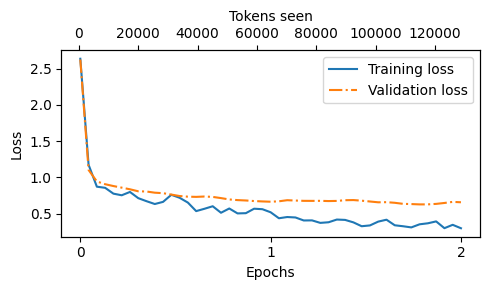

In [35]:
from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 如我们所见,损失在第一个 epoch 开始时急剧下降,这意味着模型开始快速学习- 我们可以看到轻微的过拟合大约在 1 个训练 epoch 后开始出现

&nbsp;
## 7.7 提取和保存响应 (Extracting and saving responses)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/18.webp?1" width=500px>

**Figure 7.17 — 提取、保存和评估响应的流程**

```
微调后的模型
     |
     v
对测试集生成响应
     |
     v
保存到 JSON 文件
     |
     v
用另一个 LLM (Llama 3) 评估
     |
     v
获得评分 (0-100)
```

> 微调完成后,提取模型在测试集上的响应并保存,为下一节用更大的 LLM 进行自动评估做准备。


- 在本节中,我们保存测试集响应,以便在下一节中进行评分- 我们还保存模型副本以备将来使用- 但首先,让我们简要查看微调模型生成的响应

In [36]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

- 从测试集指令、给定响应和模型响应来看,模型表现相对较好- 第一个和最后一个指令的答案明显正确- 第二个答案接近正确;模型回答了"cumulus cloud"而非"cumulonimbus"(但请注意,cumulus 云可以发展为能够产生雷暴的 cumulonimbus 云)- 最重要的是,我们可以看到模型评估不像上一章那么简单——上一章我们只需计算正确垃圾邮件/非垃圾邮件类别标签的百分比即可获得分类准确率- 在实践中,指令微调的 LLM(如聊天机器人)通过多种方法进行评估  - 简答和选择题基准测试,如 MMLU ("Measuring Massive Multitask Language Understanding", [https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)),用于测试模型的知识  - 与其他 LLM 的人类偏好对比,如 LMSYS chatbot arena ([https://arena.lmsys.org](https://arena.lmsys.org))  - 自动化对话基准测试,使用另一个 LLM(如 GPT-4)来评估响应,如 AlpacaEval ([https://tatsu-lab.github.io/alpaca_eval/](https://tatsu-lab.github.io/alpaca_eval/))- 在下一节中,我们将使用类似于 AlpacaEval 的方法,用另一个 LLM 来评估我们模型的响应;不过,我们将使用自己的测试集,而不是使用公开可用的基准数据集- 为此,我们将模型响应添加到 `test_data` 字典中,并保存为 `"instruction-data-with-response.json"` 文件以备记录,以便在需要时可以在单独的 Python 会话中加载和分析

In [37]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|█████████████████████████████████████████| 110/110 [01:08<00:00,  1.60it/s]


- 让我们检查其中一个条目,确认响应是否已正确添加到 `test_data` 字典中

In [38]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


- 最后,我们还保存模型,以备将来重复使用

In [39]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


&nbsp;
## 7.8 评估微调后的 LLM (Evaluating the finetuned LLM)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/19.webp?1" width=500px>

**Figure 7.18 — 用 Llama 3 评估微调模型的响应**

```
微调后的 GPT 模型生成响应
          |
          v
构造评估 prompt (指令+响应+参考答案)
          |
          v
发送给 Llama 3 (通过 Ollama)
          |
          v
Llama 3 返回评分 (0-100)
          |
          v
计算所有测试样本的平均分
```

> 使用更大的 LLM (Llama 3 8B) 作为评估器来评判微调模型的响应质量,这是一种无需人工标注的自动化评估方法。


- 在本节中,我们使用另一个更大的 LLM 来自动化评估微调后 LLM 的响应- 具体来说,我们使用 Meta AI 的 80 亿参数指令微调 Llama 3 模型,可以通过 ollama ([https://ollama.com](https://ollama.com)) 在本地运行- (或者,如果你更喜欢通过 OpenAI API 使用更强大的 LLM(如 GPT-4),请参阅 [llm-instruction-eval-openai.ipynb](../03_model-evaluation/llm-instruction-eval-openai.ipynb) notebook)

- Ollama 是一个高效运行 LLM 的应用程序- 它是 llama.cpp ([https://github.com/ggerganov/llama.cpp](https://github.com/ggerganov/llama.cpp)) 的封装,后者用纯 C/C++ 实现 LLM 以最大化效率- 注意,它是用于让 LLM 生成文本的工具(推理),而非训练或微调 LLM- 在运行下面的代码之前,请访问 [https://ollama.com](https://ollama.com) 并按照说明安装 ollama(例如,点击"Download"按钮,下载适用于您操作系统的 ollama 应用程序)

- macOS 和 Windows 用户,请点击下载的 ollama 应用程序;如果提示安装命令行工具,请选择"是"- Linux 用户可以使用 ollama 网站上提供的安装命令- 通常,在我们可以从命令行使用 ollama 之前,必须启动 ollama 应用程序或在单独的终端中运行 `ollama serve`<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/20.webp?1" width=700px>

**Figure 7.19 — Ollama 的安装和启动流程**

```
下载 Ollama (ollama.com)
     |
     v
启动: ollama 应用 或 `ollama serve`
     |
     v
终端运行: ollama run llama3
     |
     v
首次自动下载模型 (4.7 GB)
     |
     v
进入交互对话
```

> Ollama 将复杂的 LLM 部署简化为一条命令,本地即可运行 8B 参数的 Llama 3 模型进行推理和评估。


---

**注意**:

- 在终端中运行如上所述的 `ollama serve` 时,你可能会遇到错误消息 `Error: listen tcp 127.0.0.1:11434: bind: address already in use`- 如果出现这种情况,请尝试使用命令 `OLLAMA_HOST=127.0.0.1:11435 ollama serve`(如果该地址也被占用,尝试将端口号递增,直到找到未被占用的地址)
---

- 在另一个终端中运行 ollama 应用程序或 `ollama serve` 后,在命令行中执行以下命令来试用 80 亿参数的 Llama 3 模型(该模型占用 4.7 GB 存储空间,首次执行此命令时会自动下载)```bash
# 8B 模型
ollama run llama3
```输出如下所示```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```- 注意 `llama3` 指的是指令微调的 80 亿参数 Llama 3 模型- 使用 ollama 运行 `"llama3"` 模型(80 亿参数模型)需要 16 GB 内存;如果你的机器不支持,可以尝试更小的模型,例如 38 亿参数的 phi-3 模型,设置 `model = "phi-3"`,它只需要 8 GB 内存- 或者,如果你的机器支持,你也可以使用更大的 700 亿参数 Llama 3 模型,将 `llama3` 替换为 `llama3:70b`- 下载完成后,你将看到一个命令行提示符,允许你与模型对话- 尝试输入类似"What do llamas eat?"的提示,应该会返回类似以下的输出```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- 你可以使用输入 `/bye` 来结束此会话

- 以下代码检查 ollama 会话是否正常运行,然后再继续使用 ollama 评估我们在上一节中生成的测试集响应

In [40]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [41]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- 现在,除了之前使用的 `ollama run` 命令与模型交互外,还可以通过其 REST API 在 Python 中使用以下函数- 在运行此 notebook 中的后续单元格之前,请确保 ollama 仍在运行(之前的代码单元格应打印 `"Ollama running: True"`)- 接下来,运行以下代码单元格来查询模型

In [42]:
import requests  # noqa: F811
# import urllib.request

def query_model(
    prompt,
    model="llama3",
    # If you used OLLAMA_HOST=127.0.0.1:11435 ollama serve
    # update the address from 11434 to 11435
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    
    """
    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data
    """

    # The book originally used the commented-out above, which is based
    # on urllib. It works generally fine, but some readers reported
    # issues with using urlib when using a (company) VPN.
    # The code below uses the requests library, which doesn't seem
    # to have these issues.

    # Send the POST request
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and well-being.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, including plants like willow, alder, and birch.
2. Bark: In some cases, ll

- 注意,如果你收到 `HTTPError: 404 Client Error: Not Found for url: http://localhost:11434/api/chat` 错误,这可能意味着你还没有下载 `llama3` 模型(要下载模型,请使用 UI 或在终端中运行 `ollama run llama3`)

- 现在,使用上面定义的 `query_model` 函数,我们可以评估微调模型的响应;让我们在前几节查看的前 3 个测试集响应上试一试

In [43]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might find the comparison slightly less vivid or evocative than others. For example, comparing something to lightning (as in the original response) can be more dramatic and attention-grabbing. However, "as fast as a bullet" is still a strong and effective simile that effectively conveys the idea of the car's speed.

Overall, I think the model did a great job!

-------------------------

Dataset response:
>> The type of cloud typically a

---

**注意: 更好的评估提示**

- [一位读者 (Ayoosh Kathuria) 建议](https://github.com/rasbt/LLMs-from-scratch/discussions/449)了一个更长的改进提示,它以 1-5 的等级(而非 1 到 100)评估响应,并使用了评分标准 (grading rubric),从而产生更准确、噪声更小的评估结果:

```
prompt = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Provide your feedback as follows:

Feedback:::
Evaluation: (your rationale for the rating, as a text)
Total rating: (your rating, as a number between 1 and 5)

You MUST provide values for 'Evaluation:' and 'Total rating:' in your answer.

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}


Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
Feedback:::
Evaluation: """
```

- 更多上下文和信息,请参阅[此](https://github.com/rasbt/LLMs-from-scratch/discussions/449) GitHub 讨论
---

- 如我们所见,Llama 3 模型提供了合理的评估,如果模型不完全正确也会给部分分数,我们可以从"cumulus cloud"答案中看出- 注意,之前的提示返回非常冗长的评估;我们可以调整提示以生成 0 到 100 之间的整数响应(其中 100 为最佳),来计算我们模型的平均分- 在 M3 MacBook Air 笔记本电脑上,评估测试集中的 110 个条目大约需要 1 分钟

In [44]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|████████████████████████| 110/110 [00:37<00:00,  2.90it/s]

Number of scores: 110 of 110
Average score: 49.45



- 我们的模型获得了 50 以上的平均分,我们可以将其作为参考点,将模型与其他模型进行比较,或尝试可能改进模型的其他训练设置- 注意,截至撰写时,ollama 在不同操作系统上并非完全确定性的,因此你获得的数字可能与上面显示的略有不同

- 供参考,原始模型对比:  - Llama 3 8B 基础模型的得分为 58.51  - Llama 3 8B 指令模型的得分为 82.65

## 7.9 总结 (Conclusions)

&nbsp;
### 7.9.1 接下来做什么- 这标志着本书的最后一章- 我们涵盖了 LLM 开发生命周期的主要步骤: 实现 LLM 架构、预训练 LLM 以及对其进行微调<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/21.webp?1" width=500px>

**Figure 7.20 — LLM 开发的完整生命周期**

```
第4章: 实现 GPT 架构
         |
         v
第5章: 在通用文本上预训练
         |
         v
第6章: 分类任务微调 (垃圾邮件检测)
         |
         v
第7章: 指令微调 (遵循人类指令)
         |
         v
(可选) 偏好微调 (DPO 对齐)
```

> 本书从零开始构建了一个完整的 GPT 模型,经历预训练和微调,最终得到一个能遵循指令的对话式 LLM。指令微调之后的偏好微调是可选的进阶步骤。


&nbsp;
### 7.9.2 在快速发展的领域中保持最新- 本节没有代码

&nbsp;
### 7.9.3 结语- 我希望你享受了这段从零开始实现 LLM、编写预训练和微调函数的旅程- 在我看来,从零开始实现 LLM 是理解 LLM 工作原理的最佳方式;我希望你通过这种方法获得了更深的理解- 虽然本书服务于教育目的,但你可能希望在实际应用中使用不同且更强大的 LLM  - 为此,你可以考虑使用流行的工具,如 axolotl ([https://github.com/OpenAccess-AI-Collective/axolotl](https://github.com/OpenAccess-AI-Collective/axolotl)) 或 LitGPT ([https://github.com/Lightning-AI/litgpt](https://github.com/Lightning-AI/litgpt)),后者由我参与开发

## 总结与要点- 参见 [./gpt_instruction_finetuning.py](./gpt_instruction_finetuning.py) 脚本,这是一个自包含的指令微调脚本- [./ollama_evaluate.py](./ollama_evaluate.py) 是基于 7.8 节的独立脚本,通过 Ollama 和 Llama 3 评估包含 "output" 和 "response" 键的 JSON 文件- [./load-finetuned-model.ipynb](./load-finetuned-model.ipynb) notebook 演示了如何在新的会话中加载微调后的模型- 你可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习答案

## 接下来做什么?- 恭喜你完成了本书的学习!如果你正在寻找更多资源,我在这个 GitHub 仓库中添加了一些你可能感兴趣的附加章节- 完整的附加材料列表可以在主 README 的 [Bonus Material](https://github.com/rasbt/LLMs-from-scratch?tab=readme-ov-file#bonus-material) 部分查看- 以下是几个我特别推荐的:  1. [从零实现 DPO (Direct Preference Optimization) 用于 LLM 对齐](../04_preference-tuning-with-dpo/dpo-from-scratch.ipynb) 实现了一个流行的偏好调优机制,使本章的模型更贴近人类偏好  2. [从零实现 Llama 3.2 (独立 Notebook)](../../ch05/07_gpt_to_llama/standalone-llama32.ipynb),从零实现了 Meta AI 流行的 Llama 3.2,包括加载官方预训练权重;如果你想进行额外实验,可以用 `Llama3Model` 类替换各章中的 `GPTModel` 模型(它应该可以作为 1:1 的替代品)  3. [将 GPT 转换为 Llama](../../ch05/07_gpt_to_llama) 包含带分步指南的代码,解释 GPT-2 与各种 Llama 模型之间的差异  4. [理解 Embedding 层与 Linear 层的区别](../../ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb) 是一个概念性解释,说明 PyTorch 中的 `Embedding` 层(我们在 LLM 输入阶段使用)在数学上等价于应用于 one-hot 编码数据的线性层- 祝你阅读愉快!